In [1]:
sys.path.append("../dataloaders")

In [2]:
import torch.nn.functional as F
from data_loader_cropping_padding import CroppedPaddedDataset
import torch.nn as nn
import torch
import torchvision.models as models
from torchvision.models import ResNet18_Weights
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

In [3]:
dataset = CroppedPaddedDataset("../annot_crops.csv", "../SplitImages")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


Image width 400 and height 200
Found 328 valid samples


In [4]:
class ResNetRegressor(nn.Module):
    def __init__(self):
        super().__init__()

        self.backbone = models.resnet18(weights=ResNet18_Weights.DEFAULT)

        # regression-head
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 1)

        #Freeze First layers
        for p in self.backbone.conv1.parameters():
            p.requires_grad = False
        for p in self.backbone.bn1.parameters():
            p.requires_grad = False
        #for p in self.backbone.layer1.parameters():
        #    p.requires_grad = False
        for p in self.backbone.layer2.parameters():
            p.requires_grad = False
        for p in self.backbone.layer3.parameters():
            p.requires_grad = False
        #for p in self.backbone.layer4.parameters():
        #    p.requires_grad = False
        #for p in self.backbone.fc.parameters():
        #    p.requires_grad = False

    def forward(self, x):
        return self.backbone(x)

In [5]:
# Training, validation and test-data
val_split = 0.2   # 20% val
test_split = 0.1  # 10% test 

n_total = len(dataset)
n_test = int(n_total * test_split)
n_val = int(n_total * val_split)
n_train = n_total - n_val - n_test

#Seed
generator = torch.Generator().manual_seed(42)

train_set, val_set, test_set = random_split(
    dataset,
    [n_train, n_val, n_test],
    generator=generator
)

train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_set,   batch_size=32, shuffle=False)
test_loader  = DataLoader(test_set,  batch_size=32, shuffle=False)

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")


Train: 231, Val: 65, Test: 32


In [6]:
model_ResNet = ResNetRegressor().to(device)
state_dict = torch.load("resnet_regressor_final.pth", map_location=device)
model_ResNet.load_state_dict(state_dict)
model_ResNet.eval()

C:\Users\norae\AppData\Local\Temp\ipykernel_22544\1559016043.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load("resnet_regressor_final.pth", map_lo

ResNetRegressor(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, 

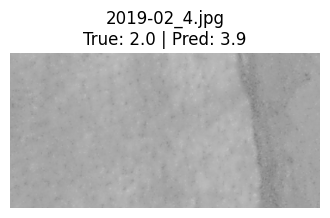

Test MSE: 7.545
Test MAE: 1.704


In [7]:
model_ResNet.eval()

test_mse = 0.0
test_mae = 0.0
n_test_samples = 0

idx = 3   

with torch.no_grad():
    for imgs, labels, names in test_loader:
        imgs = imgs.to(device)
        labels = labels.float().view(-1, 1).to(device)

        outputs = model_ResNet(imgs)

        if idx < len(imgs):
            img = imgs[idx].cpu()
            img = img * 0.5 + 0.5  

            img_np = img.permute(1, 2, 0).numpy()
            true_age = labels[idx].item()
            pred_age = outputs[idx].item()
            filename = names[idx]

            plt.figure(figsize=(4,4))
            plt.imshow(img_np)
            plt.title(f"{filename}\nTrue: {true_age:.1f} | Pred: {pred_age:.1f}")
            plt.axis("off")
            plt.show()

        mse_batch = (outputs - labels) ** 2          
        mae_batch = (outputs - labels).abs()         

        test_mse += mse_batch.sum().item()
        test_mae += mae_batch.sum().item()
        n_test_samples += labels.size(0)

test_mse /= n_test_samples
test_mae /= n_test_samples

print(f"Test MSE: {test_mse:.3f}")
print(f"Test MAE: {test_mae:.3f}")

## Grad-CAM

In [8]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.model.eval()
        self.target_layer = target_layer

        self.activations = None
        self.gradients = None

        #Save activations
        def forward_hook(module, inp, out):
            self.activations = out.detach()

        #Save gradients
        def backward_hook(module, grad_input, grad_output):
            self.gradients = grad_output[0].detach()

        self.fwd_handle = target_layer.register_forward_hook(forward_hook)
        self.bwd_handle = target_layer.register_full_backward_hook(backward_hook)

    def __call__(self, x):
        self.model.zero_grad()

        output = self.model(x)  
        target = output.squeeze()         
        target.backward(retain_graph=True)


        grads = self.gradients
        acts = self.activations

        weights = grads.mean(dim=(2, 3), keepdim=True)  
        cam = (weights * acts).sum(dim=1, keepdim=True)  
        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=x.shape[2:],
            mode="bilinear",
            align_corners=False
        )

        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min + 1e-8)
        else:
            cam = torch.zeros_like(cam)
        return cam, output.detach()


Test-image index: 7
File name: 2020-97_2.jpg
True age: 1.0
Predicted age: 1.856064796447754


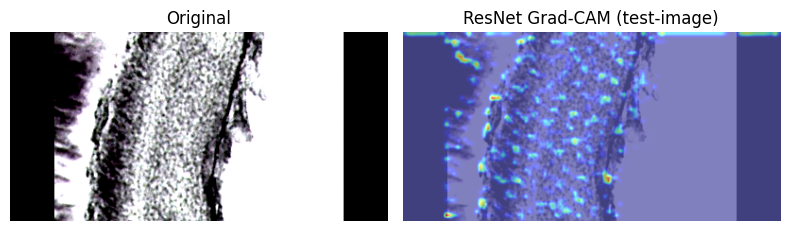

In [12]:
model_ResNet.eval()

#Layer in ResNet
target_layer_resnet = model_ResNet.backbone.layer1[-1].conv2
gradcam_resnet = GradCAM(model_ResNet, target_layer_resnet)

#Select a test image
idx = 7  #Test image number
img, label, name = test_set[idx]

img_input = img.unsqueeze(0).to(device)

#Grad-CAM
cam_resnet, pred_resnet = gradcam_resnet(img_input)

print("Test-image index:", idx)
print("File name:", name)
print("True age:", float(label))
print("Predicted age:", float(pred_resnet.item()))

img_np = img.permute(1, 2, 0).cpu().numpy()
cam_np = cam_resnet.squeeze().cpu().numpy()

fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].imshow(img_np)
ax[0].set_title("Original")
ax[0].axis("off")

ax[1].imshow(img_np, alpha=0.5)
ax[1].imshow(cam_np, alpha=0.5, cmap="jet")
ax[1].set_title("ResNet Grad-CAM (test-image)")
ax[1].axis("off")

plt.tight_layout()
plt.show()
